# FitScan AI – CV Block: Exercise Image Classification

**Dataset:** Workout/Exercise Images (Kaggle) – 22 exercise classes, ~600-700 images each  
**Goal:** Classify gym exercise images into one of 4 workout categories  
**Method:** Transfer Learning with EfficientNetB0 (pretrained on ImageNet)  
**Integration:** The predicted workout category is passed as `Workout_Type` to the ML block for calorie prediction

### Class Mapping (CV classes → ML classes)
| CV Exercise | ML Category |
|-------------|-------------|
| bench press, deadlift, squat, shoulder press, ... | Strength |
| pull up, push up, leg raises, plank, russian twist, squat | HIIT |


## 1. Imports & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('Imports successful')

TensorFlow version: 2.21.0
GPU available: False
Imports successful


## 2. Dataset Setup & Class Mapping

We map the 22 exercise classes into 4 workout categories that match the ML block.

In [2]:
# Path to your downloaded images
RAW_DATA_DIR = Path('images') 
# Mapping: exercise folder name -> ML workout category
CLASS_MAPPING = {
    'barbell biceps curl': 'Strength',
    'bench press':         'Strength',
    'chest fly machine':   'Strength',
    'deadlift':            'Strength',
    'decline bench press': 'Strength',
    'hammer curl':         'Strength',
    'hip thrust':          'Strength',
    'incline bench press':  'Strength',
    'lat pulldown':        'Strength',
    'lateral raises':      'Strength',
    'leg extension':       'Strength',
    'romanian deadlift':   'Strength',
    'shoulder press':      'Strength',
    't bar row':           'Strength',
    'tricep dips':         'Strength',
    'tricep pushdown':     'Strength',
    'pull up':             'HIIT',
    'push up':             'HIIT',
    'leg raises':          'HIIT',
    'russian twist':       'HIIT',
    'plank':               'HIIT',
    'squat':               'HIIT',
}

# Count images per class
print('Images found per exercise:')
category_counts = {'Strength': 0, 'HIIT': 0}
for exercise, category in CLASS_MAPPING.items():
    folder = RAW_DATA_DIR / exercise
    if folder.exists():
        n = len(list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + list(folder.glob('*.jpeg')))
        category_counts[category] += n
        print(f'  {exercise:<25} -> {category:<10} ({n} images)')
    else:
        print(f'  {exercise:<25} -> NOT FOUND')

print(f'\nTotal per category:')
for cat, count in category_counts.items():
    print(f'  {cat}: {count} images')

Images found per exercise:
  barbell biceps curl       -> Strength   (705 images)
  bench press               -> Strength   (625 images)
  chest fly machine         -> Strength   (527 images)
  deadlift                  -> Strength   (530 images)
  decline bench press       -> Strength   (514 images)
  hammer curl               -> Strength   (546 images)
  hip thrust                -> Strength   (557 images)
  incline bench press       -> Strength   (729 images)
  lat pulldown              -> Strength   (646 images)
  lateral raises            -> Strength   (843 images)
  leg extension             -> Strength   (586 images)
  romanian deadlift         -> Strength   (555 images)
  shoulder press            -> Strength   (512 images)
  t bar row                 -> Strength   (668 images)
  tricep dips               -> Strength   (698 images)
  tricep pushdown           -> Strength   (625 images)
  pull up                   -> HIIT       (615 images)
  push up                   -> HIIT   

## 3. Reorganize Dataset into Train / Validation / Test Split

In [6]:
import random
random.seed(42)
np.random.seed(42)

DATASET_DIR = Path('dataset_split')
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Create split directories
for split in ['train', 'val', 'test']:
    for category in ['Strength', 'HIIT']:
        (DATASET_DIR / split / category).mkdir(parents=True, exist_ok=True)

# Copy images into split folders
total_copied = 0
for exercise, category in CLASS_MAPPING.items():
    folder = RAW_DATA_DIR / exercise
    if not folder.exists():
        continue

    images = list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + list(folder.glob('*.jpeg'))
    random.shuffle(images)

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        'train': images[:n_train],
        'val':   images[n_train:n_train + n_val],
        'test':  images[n_train + n_val:]
    }

    for split, split_images in splits.items():
        for img_path in split_images:
            dest = DATASET_DIR / split / category / f"{exercise.replace(' ', '_')}_{img_path.name}"
            shutil.copy2(img_path, dest)
            total_copied += 1

print(f'Dataset split complete! Total images copied: {total_copied}')
for split in ['train', 'val', 'test']:
    for cat in ['Strength', 'HIIT']:
        n = len(list((DATASET_DIR / split / cat).glob('*')))
        print(f'  {split}/{cat}: {n} images')

KeyboardInterrupt: 

## 4. Data Preprocessing & Augmentation

In [7]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
DATASET_DIR = Path('dataset_split') 

from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    DATASET_DIR / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    DATASET_DIR / 'test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Class names: {CLASS_NAMES}')
print(f'Class indices: {train_gen.class_indices}')

with open('cv_class_names.pkl', 'wb') as f:
    pickle.dump(CLASS_NAMES, f)
print('Class names saved: cv_class_names.pkl')

Found 9687 images belonging to 2 classes.
Found 2067 images belonging to 2 classes.
Found 2099 images belonging to 2 classes.
Class names: ['HIIT', 'Strength']
Class indices: {'HIIT': 0, 'Strength': 1}
Class names saved: cv_class_names.pkl


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..211.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..230.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..227.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..213.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..217.0].
Clipping input data to the valid range for imshow with RGB dat

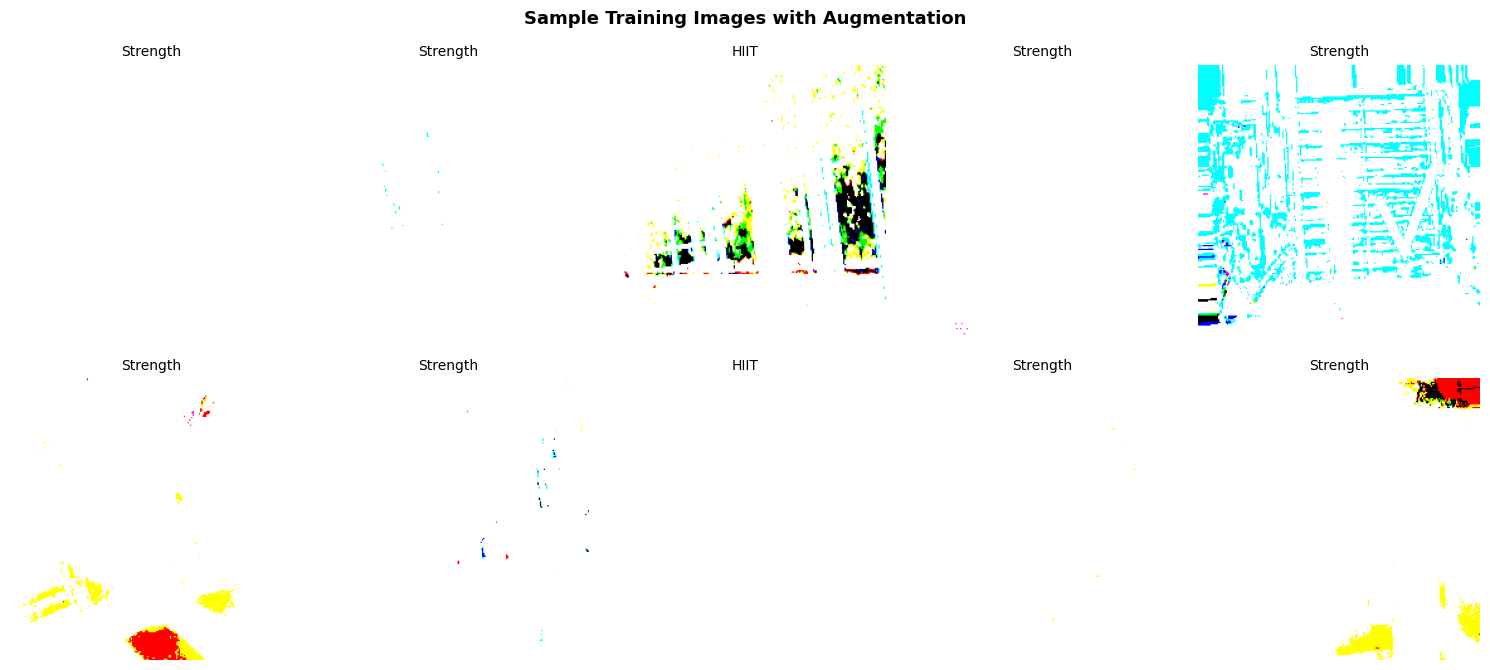

Sample images saved: sample_images.png


In [9]:
# Visualize sample training images
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Sample Training Images with Augmentation', fontsize=13, fontweight='bold')

batch_images, batch_labels = next(train_gen)
for i, ax in enumerate(axes.flat):
    if i < len(batch_images):
        ax.imshow(batch_images[i])
        label_idx = np.argmax(batch_labels[i])
        ax.set_title(CLASS_NAMES[label_idx], fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample images saved: sample_images.png')

In [10]:
from sklearn.utils.class_weight import compute_class_weight

# Class weights to handle imbalance (Strength ~2.5x more images than HIIT)
classes = np.array([0, 1])  # HIIT=0, Strength=1
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')
# Expected: HIIT (0) gets higher weight ~2.5x, Strength (1) lower

Class weights: {0: np.float64(1.7372668579626973), 1: np.float64(0.7020582693143934)}


## 5. Model – Transfer Learning with EfficientNetB0

We use EfficientNetB0 pretrained on ImageNet as feature extractor and add custom classification layers on top.

In [11]:
NUM_CLASSES = len(CLASS_NAMES)

def build_model():
    # Load EfficientNetB0 pretrained on ImageNet, without the top classifier
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    # Freeze base model weights (feature extraction only)
    base_model.trainable = False

    # Add custom classification head
    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Number of classes: {NUM_CLASSES}')
print(f'Trainable params: {model.count_params():,}')
model.summary()

Number of classes: 2
Trainable params: 4,415,781


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,781 (16.84 MB)

 Trainable params: 363,650 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 6. Iteration 1 – Feature Extraction (frozen base model)

**Objective:** Train only the custom classification head while keeping EfficientNetB0 weights frozen.

In [12]:
print('=' * 55)
print('ITERATION 1: Feature Extraction (frozen base model)')
print('=' * 55)

callbacks_iter1 = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_iter1,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on validation set
val_loss1, val_acc1 = model.evaluate(val_gen, verbose=0)
print(f'\nIteration 1 Results:')
print(f'  Val Accuracy: {val_acc1:.4f}')
print(f'  Val Loss:     {val_loss1:.4f}')

ITERATION 1: Feature Extraction (frozen base model)
Epoch 1/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 113s 353ms/step - accuracy: 0.9278 - loss: 0.1950 - val_accuracy: 0.9797 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 2/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 114s 377ms/step - accuracy: 0.9715 - loss: 0.0805 - val_accuracy: 0.9927 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 3/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 107s 351ms/step - accuracy: 0.9774 - loss: 0.0626 - val_accuracy: 0.9961 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 4/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 109s 358ms/step - accuracy: 0.9805 - loss: 0.0559 - val_accuracy: 0.9937 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 5/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 108s 356ms/step - accuracy: 0.9863 - loss: 0.0399 - val_accuracy: 0.9956 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 6/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 109s 360ms/step - accuracy: 0.9864 - loss: 0.0381 - val_accuracy: 0.9947 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 7/20
3

## 7. Iteration 2 – Fine-Tuning (unfreeze top layers)

**Objective:** Unfreeze the top layers of EfficientNetB0 and fine-tune with a lower learning rate to improve accuracy.

In [13]:
print('=' * 55)
print('ITERATION 2: Fine-tuning (unfreeze top 30 layers)')
print('=' * 55)

# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen layers in base model: {trainable_count}')

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_iter2 = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint('best_cv_model.keras', save_best_only=True, monitor='val_accuracy')
]

history2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_iter2,
    verbose=1
)

val_loss2, val_acc2 = model.evaluate(val_gen, verbose=0)
print(f'\nIteration 2 Results:')
print(f'  Val Accuracy: {val_acc2:.4f}')
print(f'  Val Loss:     {val_loss2:.4f}')
print(f'\nImprovement over Iteration 1: {(val_acc2 - val_acc1)*100:+.2f}%')

ITERATION 2: Fine-tuning (unfreeze top 30 layers)
Unfrozen layers in base model: 30
Epoch 1/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 136s 422ms/step - accuracy: 0.9458 - loss: 0.1493 - val_accuracy: 0.9840 - val_loss: 0.0453 - learning_rate: 1.0000e-05
Epoch 2/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 127s 419ms/step - accuracy: 0.9635 - loss: 0.1009 - val_accuracy: 0.9889 - val_loss: 0.0374 - learning_rate: 1.0000e-05
Epoch 3/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 129s 426ms/step - accuracy: 0.9730 - loss: 0.0752 - val_accuracy: 0.9903 - val_loss: 0.0313 - learning_rate: 1.0000e-05
Epoch 4/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 133s 439ms/step - accuracy: 0.9781 - loss: 0.0608 - val_accuracy: 0.9918 - val_loss: 0.0266 - learning_rate: 1.0000e-05
Epoch 5/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 134s 442ms/step - accuracy: 0.9787 - loss: 0.0555 - val_accuracy: 0.9927 - val_loss: 0.0237 - learning_rate: 1.0000e-05
Epoch 6/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 131s 433ms/step - accuracy: 0.9841 - loss: 0.0466 - val_accuracy: 0.9942 - v

## 8. Training History Visualization

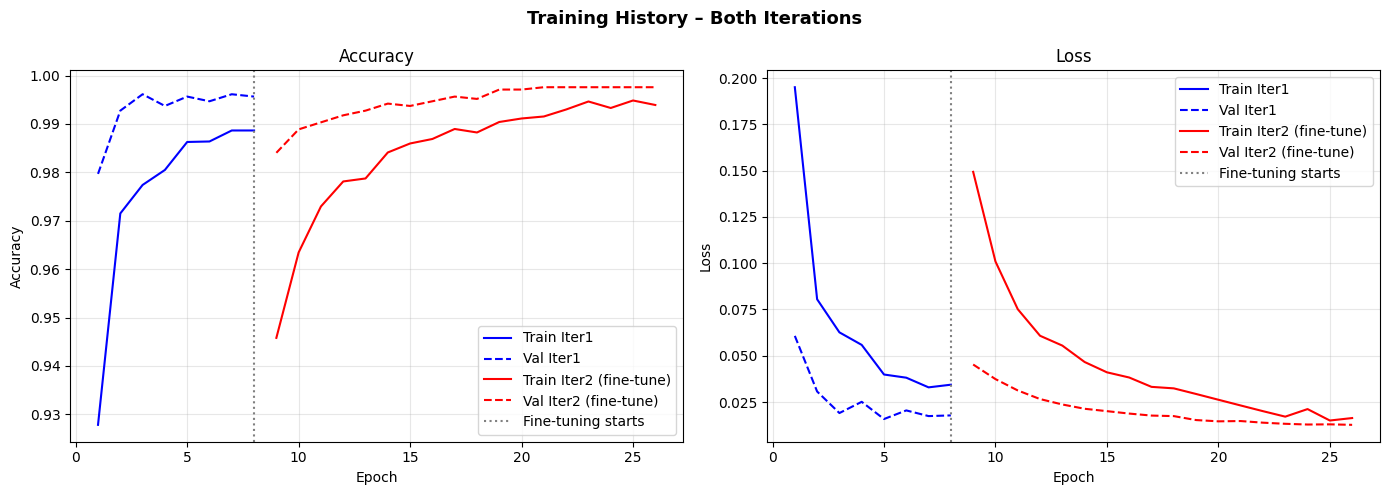

Training history saved: cv_training_history.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History – Both Iterations', fontsize=13, fontweight='bold')

# Combine histories
acc1  = history1.history['accuracy']
vacc1 = history1.history['val_accuracy']
acc2  = history2.history['accuracy']
vacc2 = history2.history['val_accuracy']

e1 = range(1, len(acc1) + 1)
e2 = range(len(acc1) + 1, len(acc1) + len(acc2) + 1)

# Accuracy
axes[0].plot(e1, acc1,  'b-',  label='Train Iter1')
axes[0].plot(e1, vacc1, 'b--', label='Val Iter1')
axes[0].plot(e2, acc2,  'r-',  label='Train Iter2 (fine-tune)')
axes[0].plot(e2, vacc2, 'r--', label='Val Iter2 (fine-tune)')
axes[0].axvline(x=len(acc1), color='gray', linestyle=':', label='Fine-tuning starts')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
loss1  = history1.history['loss']
vloss1 = history1.history['val_loss']
loss2  = history2.history['loss']
vloss2 = history2.history['val_loss']

axes[1].plot(e1, loss1,  'b-',  label='Train Iter1')
axes[1].plot(e1, vloss1, 'b--', label='Val Iter1')
axes[1].plot(e2, loss2,  'r-',  label='Train Iter2 (fine-tune)')
axes[1].plot(e2, vloss2, 'r--', label='Val Iter2 (fine-tune)')
axes[1].axvline(x=len(acc1), color='gray', linestyle=':', label='Fine-tuning starts')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cv_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training history saved: cv_training_history.png')

## 9. Final Evaluation on Test Set

Test Accuracy: 0.9967
Test Loss:     0.0148

Classification Report:
              precision    recall  f1-score   support

        HIIT       1.00      0.99      0.99       603
    Strength       1.00      1.00      1.00      1496

    accuracy                           1.00      2099
   macro avg       1.00      1.00      1.00      2099
weighted avg       1.00      1.00      1.00      2099



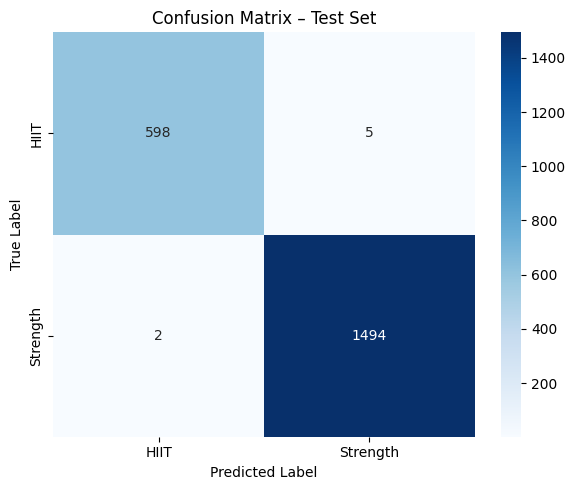

Confusion matrix saved: cv_confusion_matrix.png


In [15]:
# Load best model
best_model_cv = keras.models.load_model('best_cv_model.keras')

# Evaluate on test set
test_loss, test_acc = best_model_cv.evaluate(test_gen, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss:     {test_loss:.4f}')

# Predictions
test_gen.reset()
y_pred_probs = best_model_cv.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix – Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('cv_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved: cv_confusion_matrix.png')

## 10. Predict Function (used in app.py)

This function takes an image and returns the predicted workout category (`Strength` or `HIIT`), which is then passed to the ML block.

In [17]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_exercise(img_path, model=None, class_names=None):
    """
    Predict workout category from an exercise image.

    Parameters:
        img_path: path to image file
        model: loaded Keras model (best_cv_model.keras)
        class_names: list of class names ['HIIT', 'Strength']

    Returns:
        predicted_class (str): e.g. 'Strength' or 'HIIT'
        confidence (float): prediction confidence 0-1
        all_probs (dict): probabilities for all classes
    """
    if model is None:
        model = best_model_cv
    if class_names is None:
        class_names = CLASS_NAMES

    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs = model.predict(img_array, verbose=0)[0]
    predicted_idx = np.argmax(probs)
    predicted_class = class_names[predicted_idx]
    confidence = float(probs[predicted_idx])
    all_probs = {cls: float(p) for cls, p in zip(class_names, probs)}

    return predicted_class, confidence, all_probs


# Quick test with a sample image from test set
test_images = list((DATASET_DIR / 'test' / 'Strength').glob('*'))[:1]
if test_images:
    pred_class, conf, all_probs = predict_exercise(test_images[0])
    print(f'Test image: {test_images[0].name}')
    print(f'Predicted:  {pred_class} (confidence: {conf:.2%})')
    print(f'All probs:  {all_probs}')
    print('\nCV block complete! Next: build app.py')

Test image: bench_press_bench press_2900021.jpg
Predicted:  Strength (confidence: 91.46%)
All probs:  {'HIIT': 0.08542963117361069, 'Strength': 0.9145703911781311}

CV block complete! Next: build app.py


## 11. Save Model for Deployment

In [18]:
# Save in SavedModel format for HuggingFace deployment
best_model_cv.save('cv_model_final.keras')

print('Model saved: cv_model_final.keras')
print(' Class names: cv_class_names.pkl')
print(f'\nModel summary:')
print(f'  Input:   (224, 224, 3)')
print(f'  Output:  {NUM_CLASSES} classes -> {CLASS_NAMES}')
print(f'  Mapping: Strength -> Strength (for ML block)')
print(f'           HIIT     -> HIIT     (for ML block)')
print('\n All done! Files needed for app.py:')
print('  - cv_model_final.keras')
print('  - cv_class_names.pkl')
print('  - calories_model.pkl')
print('  - label_encoder_workout.pkl')
print('  - label_encoder_gender.pkl')

Model saved: cv_model_final.keras
 Class names: cv_class_names.pkl

Model summary:
  Input:   (224, 224, 3)
  Output:  2 classes -> ['HIIT', 'Strength']
  Mapping: Strength -> Strength (for ML block)
           HIIT     -> HIIT     (for ML block)

 All done! Files needed for app.py:
  - cv_model_final.keras
  - cv_class_names.pkl
  - calories_model.pkl
  - label_encoder_workout.pkl
  - label_encoder_gender.pkl
